# LLM Tracker — Discovery Mode Tutorial

Discovery mode is the **inverse of coding**. Instead of giving the LLM a codebook and asking it to find those constructs, you give it a *theoretical framework* and ask it to discover whatever constructs from that framework appear in your documents.

The workflow:
1. **Discover** — the LLM reads each document through a framework (e.g. Cognitive behavioral therapy) and reports the constructs it finds, with supporting quotes.
2. **Merge** — constructs discovered across many documents are consolidated into canonical constructs, each with an LLM-synthesized name, a definition, and its constituent constructs ranked by *prototypicality*.
3. **Review** — inspect the consolidated constructs, their frequency, and sample quotes.
4. **Build a codebook** — turn the discovered constructs into a codebook you can feed to the coding pipeline (see the main tutorial).

#TODO

expose merging prompt here so users can edit, 
consider ignoring low-freq constiuents that are not very protypical 
Reduce hetergenocity 

## 1. Install

In [ ]:
!pip install "git+https://github.com/childmindresearch/llm_tracker.git#egg=llm-tracker[tutorials]"

## 2. Imports

In [5]:
import random

import pandas as pd

from llm_tracker import AnalyzerConfig
from llm_tracker.discovery import (
    LLMTrackerDiscoverer,
    discovery_to_codebook,
    format_merged_constructs,
    merge_constructs,
)

## 3. Configuration

- `api_key` — your OpenRouter API key, **or** the path to a `.env` file containing it.
- `llm_model` — any model listed at https://openrouter.ai/models.
- `input_data` — your documents (see the note on input types below).
- `framework` — the theoretical lens to discover through. Use one of the built-in defaults or write your own string.

In [6]:
api_key = "/Users/freymon.perez/Projects/GitHub/llm_tracker/openrouter_api.env"
llm_model = "google/gemini-3-flash-preview"
input_data = "sample_data/reddit_autism_anxiety_depression.csv"
framework = "Cognitive behavioral therapy"  # any of the defaults, or your own string
temperature = 0  # 0 = deterministic/reproducible

config = AnalyzerConfig(
    api_key=api_key,
    model_name=llm_model,
    temperature=temperature,
)

### A note on input types (CSV vs. directory)

`discover()` accepts the **same inputs as the coding pipeline**, and figures out which you gave it:

- **A CSV file** — one document per *row*. You must tell it which column holds the text (`text_column`), and optionally which column to use as the document ID (`id_column`); without one, the row number is used. This is what the sample data below uses.
- **A directory** — one document per *file* (`.txt` or `.csv` files in a folder). Each file's name becomes its document ID. Use this when your documents are separate files, e.g. a folder of interview transcripts saved as `.txt`.

You don't call different functions for these — just pass a file path or a folder path to `discover()` and it routes automatically. (For a directory, `text_column` is ignored.)

## 4. Discover

One LLM call per document. Each document's discovered constructs (with quotes) are returned and, because we pass `output_dir`, saved to disk under `LLM_discovery_<timestamp>/discoveries/`.

In [7]:
discoverer = LLMTrackerDiscoverer(config=config)

# CSV input -> text_column is required.
discoveries, disc_metadata, disc_errors = discoverer.discover(
    input_data,
    framework=framework,
    text_column="post",
    output_dir="LLM_discovery",
)

print(f"\nDiscovered constructs in {len(discoveries)} documents.")

Discovering [1/60]: 0


Task exception was never retrieved
future: <Task finished name='Task-291' coro=<AsyncClient.aclose() done, defined at /Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_client.py:1978> exception=RuntimeError('Event loop is closed')>
Traceback (most recent call last):
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_client.py", line 1985, in aclose
    await self._transport.aclose()
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_transports/default.py", line 406, in aclose
    await self._pool.aclose()
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpcore/_async/connection_pool.py", line 353, in aclose
    await self._close_connections(closing_connections)
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpcore/_async/connection_pool.py", line 345, in _close

  OK: Found 6 construct(s)
Discovering [2/60]: 1
  OK: Found 5 construct(s)
Discovering [3/60]: 2
  OK: Found 4 construct(s)
Discovering [4/60]: 3


Task exception was never retrieved
future: <Task finished name='Task-301' coro=<AsyncClient.aclose() done, defined at /Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_client.py:1978> exception=RuntimeError('Event loop is closed')>
Traceback (most recent call last):
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_client.py", line 1985, in aclose
    await self._transport.aclose()
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_transports/default.py", line 406, in aclose
    await self._pool.aclose()
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpcore/_async/connection_pool.py", line 353, in aclose
    await self._close_connections(closing_connections)
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpcore/_async/connection_pool.py", line 345, in _close

  OK: Found 4 construct(s)
Discovering [5/60]: 4
  OK: Found 4 construct(s)
Discovering [6/60]: 5
  OK: Found 3 construct(s)
Discovering [7/60]: 6


...

  OK: Found 4 construct(s)
Discovering [53/60]: 52
  OK: Found 4 construct(s)
Discovering [54/60]: 53
  OK: Found 3 construct(s)
Discovering [55/60]: 54


Task exception was never retrieved
future: <Task finished name='Task-502' coro=<AsyncClient.aclose() done, defined at /Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_client.py:1978> exception=RuntimeError('Event loop is closed')>
Traceback (most recent call last):
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_client.py", line 1985, in aclose
    await self._transport.aclose()
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_transports/default.py", line 406, in aclose
    await self._pool.aclose()
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpcore/_async/connection_pool.py", line 353, in aclose
    await self._close_connections(closing_connections)
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpcore/_async/connection_pool.py", line 345, in _close

  OK: Found 5 construct(s)
Discovering [56/60]: 55
  OK: Found 4 construct(s)
Discovering [57/60]: 56
  OK: Found 3 construct(s)
Discovering [58/60]: 57


Task exception was never retrieved
future: <Task finished name='Task-513' coro=<AsyncClient.aclose() done, defined at /Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_client.py:1978> exception=RuntimeError('Event loop is closed')>
Traceback (most recent call last):
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_client.py", line 1985, in aclose
    await self._transport.aclose()
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpx/_transports/default.py", line 406, in aclose
    await self._pool.aclose()
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpcore/_async/connection_pool.py", line 353, in aclose
    await self._close_connections(closing_connections)
  File "/Users/freymon.perez/Projects/GitHub/llm_tracker/.venv/lib/python3.12/site-packages/httpcore/_async/connection_pool.py", line 345, in _close

  OK: Found 5 construct(s)
Discovering [59/60]: 58
  OK: Found 3 construct(s)
Discovering [60/60]: 59
  OK: Found 5 construct(s)

Discovery complete: 60/60 documents, 0 error(s).

Discovered constructs in 60 documents.


**Directory input instead?** If your documents are separate `.txt` files in a folder, the call is even simpler — no `text_column` needed:

```python
discoveries, disc_metadata, disc_errors = discoverer.discover(
    "path/to/my_documents/",
    framework=framework,
    output_dir="LLM_discovery",
)
```

In [ ]:
#TODO, format a table. 
#get freq, remove any trailing spaces, caps, other formatting mistakes. 
discoveries

{'0': [{'construct': 'Negative Core Beliefs',
   'description': 'The individual expresses a fundamental, global negative self-evaluation regarding their personal value and social appeal.',
   'quotes': ["I'm not a interesting person"]},
  {'construct': 'Cognitive Distortion: Labeling',
   'description': 'The individual applies derogatory labels to their own interests, viewing them as inherently negative or inadequate for social connection.',
   'quotes': ['And i feel like saying watching tv, reading, fishing are all kinda boring and introverted answers.']},
  {'construct': 'Social Anxiety',
   'description': 'The individual experiences significant distress and apprehension regarding social interactions and the potential for negative evaluation by others.',
   'quotes': ['I know my anxiety has made it hard for me to get a job in the past.',
    'How many people here work and had a hard time being around new people?']},
  {'construct': 'Anticipatory Anxiety',
   'description': 'The indiv

## 5. Merge / consolidate

The constructs discovered across all documents are consolidated into canonical constructs. One LLM call proposes the grouping, canonical names, definitions, and a **prototypicality** score (0–1) for each constituent — how central it is to the consolidated meaning (1 = the first thing that comes to mind).

In [8]:
merged = merge_constructs(
    discoveries,
    config=config,
    framework=framework,
    output_path="merged_constructs.json",
)

# Review table: one row per constituent, grouped by canonical construct,
# sorted by prototypicality (highest first).
format_merged_constructs(merged)

,canonical_construct,definition,constituent,prototypicality
0,Anxiety and Physiological Arousal,The subjective experience of apprehension and ...,Anxiety,1.00
1,Anxiety and Physiological Arousal,The subjective experience of apprehension and ...,Somatic Symptoms,0.95
2,Anxiety and Physiological Arousal,The subjective experience of apprehension and ...,Somatic symptoms,0.95
3,Anxiety and Physiological Arousal,The subjective experience of apprehension and ...,Somatic symptoms of anxiety,0.95
4,Anxiety and Physiological Arousal,The subjective experience of apprehension and ...,Somatic Symptoms of Anxiety,0.95
...,...,...,...,...
147,Self-Efficacy and Locus of Control,"Beliefs regarding one's own agency, competence...",Low Self-Efficacy,1.00
148,Self-Efficacy and Locus of Control,"Beliefs regarding one's own agency, competence...",Learned Helplessness,0.95
149,Self-Efficacy and Locus of Control,"Beliefs regarding one's own agency, competence...",External Locus of Control,0.90
150,Self-Efficacy and Locus of Control,"Beliefs regarding one's own agency, competence...",Self-Blame,0.85


In [ ]:
#TODO add consti. quotes, sep by semi col, empty space

If the merge prints warnings about constructs that were dropped, not placed, or given invalid scores, that is the model imperfectly following the consolidation instructions. The result is still returned for inspection — the warnings tell you exactly what to check.

## 6. Frequency of each consolidated construct

How often did each canonical construct appear — i.e. in how many documents? We map every discovered construct back to the canonical construct it was merged into, then count the distinct documents each canonical construct showed up in.

In [9]:
# Map each constituent (original discovered name) -> its canonical construct.
constituent_to_canonical = {}
for canonical, data in merged.items():
    for c in data["constituents"]:
        constituent_to_canonical[c["name"]] = canonical

# Count, per canonical construct, how many documents it appeared in.
docs_per_construct = {canonical: set() for canonical in merged}
for doc_id, found in discoveries.items():
    for entry in found:
        canonical = constituent_to_canonical.get(entry["construct"])
        if canonical is not None:
            docs_per_construct[canonical].add(doc_id)

frequency = (
    pd.DataFrame(
        [
            {"construct": canonical, "n_documents": len(docs)}
            for canonical, docs in docs_per_construct.items()
        ]
    )
    .sort_values("n_documents", ascending=False)
    .reset_index(drop=True)
)
frequency

,construct,n_documents
0,Cognitive Distortions,35
1,Negative Core Beliefs,26
2,Emotional Regulation and Reactivity,23
3,Anxiety and Physiological Arousal,20
4,Automatic Thoughts and Rumination,16
5,Cognitive Appraisal and Processing,15
6,Coping Mechanisms and Behavioral Interventions,15
7,Avoidance and Safety Behaviors,12
8,Environmental and Interpersonal Stressors,12
9,Depressive Affect and Suicidality,11


## 7. Bar chart of construct frequency

Matplotlib is building the font cache; this may take a moment.


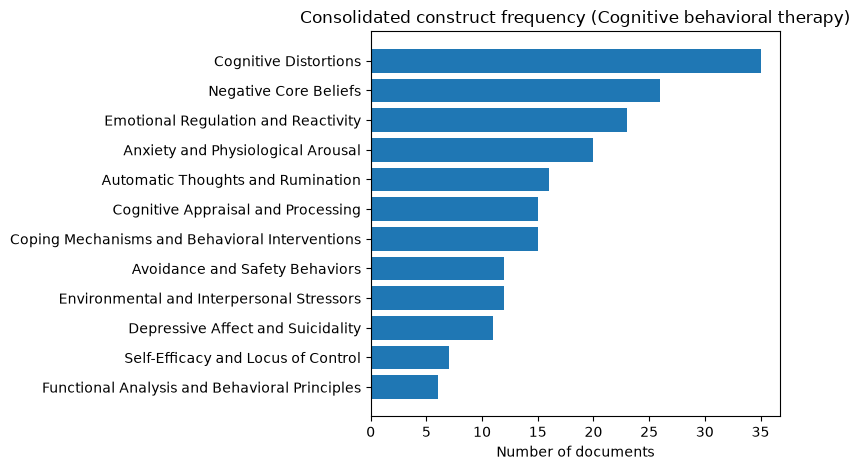

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(frequency))))
ax.barh(frequency["construct"], frequency["n_documents"])
ax.invert_yaxis()  # highest frequency at the top
ax.set_xlabel("Number of documents")
ax.set_title(f"Consolidated construct frequency ({framework})")
plt.tight_layout()
plt.show()

## 8. Sample quotes per construct

Two random quotes for each canonical construct, gathered from the documents where its constituents were discovered. (Quotes live in the per-document discoveries, not the merged summary, so we pull them from `discoveries`.)

In [13]:
random.seed(0)  # reproducible sample

# Gather all quotes per canonical construct.
quotes_per_construct = {canonical: [] for canonical in merged}
for found in discoveries.values():
    for entry in found:
        canonical = constituent_to_canonical.get(entry["construct"])
        if canonical is not None:
            quotes_per_construct[canonical].extend(entry.get("quotes", []))

# Up to 2 random quotes each.
sample_rows = []
for canonical, quotes in quotes_per_construct.items():
    chosen = random.sample(quotes, min(2, len(quotes)))
    for q in chosen:
        sample_rows.append({"construct": canonical, "quote": q})

pd.DataFrame(sample_rows, columns=["construct", "quote"])

,construct,quote
0,Negative Core Beliefs,I feel like a husky of a human.
1,Negative Core Beliefs,I have no one
2,Cognitive Distortions,i feel so hopless.
3,Cognitive Distortions,"I should feel happy about that, but I don’t."
4,Automatic Thoughts and Rumination,maybe things will get better at 18?
5,Automatic Thoughts and Rumination,I feel like kids these days are losing that ea...
6,Anxiety and Physiological Arousal,I can’t even eat anymore cause I’m anxious
7,Anxiety and Physiological Arousal,my mind in racing lately
8,Avoidance and Safety Behaviors,I do this sparingly
9,Avoidance and Safety Behaviors,my anxiety keeps me from going to my classes


## 9. Turn the discoveries into a codebook

`discovery_to_codebook` converts the consolidated constructs into a codebook in the **same format the coding pipeline uses** — so discovery can seed a coding run. Each canonical construct becomes an entry with the definition synthesized during merging. (Examples are left empty for now; you can add them by hand, or let the codebook optimizer add them after a coding run.)

In [14]:
import json

codebook = discovery_to_codebook(merged, name=f"{framework} (discovered)")

# Save it so the coding pipeline can load it by path.
with open("discovered_codebook.json", "w", encoding="utf-8") as f:
    json.dump(codebook, f, indent=2, ensure_ascii=False)

# Peek at the constructs and their definitions.
for name, entry in codebook["codebook"].items():
    print(f"- {name}: {entry['definition']}")

- Negative Core Beliefs: Deep-seated, global, and stable internal schemas regarding the self, others, and the world that shape how an individual processes information.
- Cognitive Distortions: Systematic errors in thinking or biased information processing that reinforce negative emotions and maladaptive beliefs.
- Automatic Thoughts and Rumination: Spontaneous, repetitive, and often intrusive mental activity that occurs in response to specific triggers or stressors.
- Anxiety and Physiological Arousal: The subjective experience of apprehension and the accompanying physical manifestations of the autonomic nervous system's stress response.
- Avoidance and Safety Behaviors: Maladaptive behavioral strategies used to prevent, escape, or mitigate perceived threats and emotional discomfort.
- Depressive Affect and Suicidality: A cluster of symptoms including low mood, loss of pleasure, emotional blunting, and thoughts of self-harm or death.
- Emotional Regulation and Reactivity: The processes

### Next: code with your discovered codebook

You now have `discovered_codebook.json` in the standard codebook format. You can feed it straight into the coding pipeline exactly as in the main tutorial — point `codebook_path` at this file and run `LLMTrackerAnalyzer`. Discovery → codebook → coding closes the loop: discover what's there, then measure it systematically.

You may want to review and edit the codebook first — tighten definitions, drop constructs you don't need, or add example quotes — since discovery is exploratory and its output benefits from a human pass before it becomes a measurement instrument.